# 🐻‍❄️ 투빅스 정규세션 4주차 1교시 Image Generative AI 코드 과제 🐻‍❄️



## 과제 목적
이번 과제에서는 이미지 생성 모델의 세 가지 큰 축인 **VAE**, **GAN**, **Diffusion**의 핵심 구현을 직접 코드로 뜯어보고, 마지막으로 Hugging Face의 사전학습 Diffusion 모델을 API처럼 불러와 실습해봅니다.
끝에는 직접 자기가 원하는 모델을 선택 후 써보는 경험까지 고안해보며 활용 능력까지 얻을 수 있도록 해봅니다.




## 제출물

1. 빈칸을 모두 채우고 **전부 실행한** 이 노트북 (출력 포함)
2. 기술블로그 '과제 복습' 섹션 — 마지막에 모델 활용한 [hugging face] question 4 부분만




- **VAE (Variational AutoEncoder)**: 입력 데이터를 확률적인 잠재 공간(latent space)으로 압축한 뒤, 그 분포에서 샘플링하여 새로운 데이터를 생성하는 모델
- **GAN (Generative Adversarial Network)**: Generator(위조지폐범)와 Discriminator(경찰)가 서로 경쟁하며 학습하는 모델
- **Diffusion Model**: 이미지에 점진적으로 노이즈를 주입(Forward process)한 뒤, 그 노이즈를 단계적으로 제거(Reverse process)하도록 학습하여 무작위 노이즈로부터 이미지를 생성하는 모델

Part 1~3에서는 세 모델을 MNIST로 직접 구현/학습하며 원리를 비교하고, Part 4에서는 Hugging Face `diffusers` 라이브러리로 실제 학습된 대형 Diffusion 모델을 실습합니다.


### **모듈 임포트 및 디바이스 설정**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


### **데이터셋 준비 (MNIST dataset)**

In [2]:
batch_size = 128
epochs = 15

transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.92MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 128kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.2MB/s]


## **Part 1. VAE (Variational AutoEncoder) 모델 정의 및 학습**

* Encoder: 입력 데이터 x를 받아 잠재 공간(Latent Space)의 파라미터를 추출
  * 고차원의 입력데이터를 저차원의 평균과 로그 분산으로 변환
    * 💡 빈칸 채우기 hint) `self.fc1`을 거쳐 특징을 추출한 뒤, 두 개의 서로 다른 선형 레이어를 통해 각각 평균과 로그 분산을 계산

* Latent Space & Reparameterization
  * 잠재 변수 z를 직접 고정된 값으로 뽑는 것이 아니라, encoder가 만든 분포(평균, 로그 분산)에서 샘플링함
  * Reparameterization Trick: backpropagation는 샘플링 연산을 통과할 수 없다는 문제를 해결하기 위해 샘플링 과정을 미분 가능한 형태로 만들기 위한 수식

* Decoder
  * 샘플링된 잠재 변수 z를 다시 원래의 입력 데이터 차원으로 복원


참고 코드: https://github.com/NoviceStone/VAE/blob/master/models.py

In [3]:
class VAE(nn.Module):

    def __init__(self, input_size=784, hidden_size=400, latent_size=20):
        super(VAE, self).__init__()

        # Encoder: layers
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc21 = nn.Linear(hidden_size, latent_size)  # 평균(mu)
        self.fc22 = nn.Linear(hidden_size, latent_size)  # 로그 분산(logvar)

        # Decoder: layers
        self.fc3 = nn.Linear(latent_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, input_size)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        mu = self.fc21(h1)   # 🤔 빈칸을 채워주세요 (h1을 받아 평균을 계산하는 레이어)
        logvar = self.fc22(h1)   # 🤔 빈칸을 채워주세요 (h1을 받아 로그 분산을 계산하는 레이어)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std   # 🤔 빈칸을 채워주세요 (Reparameterization Trick 수식)

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


# **✍️ 위에서 채운 `encode` / `reparameterize` 코드가 각각 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* encode 함수는 입력 데이터 x를 은닉층 fc1과 ReLU를 거쳐 특징 h1으로 변환한 뒤, 이를 두 선형 레이어 fc21과 fc22에 각각 통과시켜 잠재 공간의 확률 분포를 결정하는 평균(mu)과 로그 분산(logvar)을 계산합니다. 이어지는 reparameterize 함수는 logvar로부터 표준편차(std)를 구하고 표준정규분포에서 무작위 노이즈(eps)를 추출하여 mu + eps * std 수식을 적용하는데, 이는 무작위 샘플링 연산을 노이즈 단으로 분리함으로써 역전파 시 가중치 미분이 가능하도록 만든 Reparameterization Trick을 수행합니다.

### **VAE loss (ELBO)**
* Reconstruction Loss: 복원된 이미지(`recon_x`)가 원본 이미지(`x`)와 얼마나 다른지 측정
* KL Divergence: 잠재공간의 분포가 표준 정규분포와 얼마나 다른지 측정


In [4]:
def elbo_loss(x, recon_x, mu, logvar):

    B = x.size(0)

    x = x.view(-1, 784)

    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum') / B  # 🤔 빈칸을 채워주세요

    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / B  # 🤔 빈칸을 채워주세요

    total_loss = BCE + KLD  # 🤔 빈칸을 채워주세요

    return total_loss


**✍️ 위에서 채운 `elbo_loss` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* elbo_loss는 VAE가 원본 이미지를 잘 복원하면서도 잠재 공간을 다루기 쉬운 표준 정규분포로 정렬하도록 학습시키는 최종 손실 함수를 계산합니다.
Reconstruction Loss와 KL Divergence로 구성되어 있습니다. Reconstruction loss는 F.binary_cross_entropy(recon_x,x)를 사용해 모델이 입력을 정확히 재구성하도록 유도하고, KL Divergence는 인코더가 만든 잠재 분포와 표준 정규 분포사이의 유사도를 측정합니다.


## **🙋 [VAE] Question 1**
VAE의 ELBO Loss에 KL Divergence 항이 포함되는 이유를 설명해주세요.



* Reconstruction Loss 만 존재할 경우, 인코더는 입력 데이터를 구분하기 쉽도록 latent space를 구성하여 무작위 샘플링 시 새로운 이미지를 제대로 생성하지 못합니다. KL Divergence는 latent space가 prior 분포인 표준정규분포와 유사해지도록 만들어 자연스러운 이미지 생성에 도움을 줍니다.


In [5]:
vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

for epoch in range(epochs):

    # ========== Train ==========
    vae.train()
    train_loss = 0

    for x, _ in train_loader:

        x = x.to(device)

        recon, mu, logvar = vae(x)

        loss = elbo_loss(x, recon, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_dataset)

    # ========== Validation ==========
    vae.eval()
    val_loss = 0

    with torch.no_grad():
        for x, _ in val_loader:
            x = x.to(device)
            recon, mu, logvar = vae(x)
            loss = elbo_loss(x, recon, mu, logvar)
            val_loss += loss.item()

    val_loss /= len(val_dataset)

    print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


Epoch [1/15] Train Loss: 1.3046 | Val Loss: 1.0215
Epoch [2/15] Train Loss: 0.9616 | Val Loss: 0.9217
Epoch [3/15] Train Loss: 0.9024 | Val Loss: 0.8898
Epoch [4/15] Train Loss: 0.8786 | Val Loss: 0.8743
Epoch [5/15] Train Loss: 0.8642 | Val Loss: 0.8638
Epoch [6/15] Train Loss: 0.8549 | Val Loss: 0.8543
Epoch [7/15] Train Loss: 0.8478 | Val Loss: 0.8487
Epoch [8/15] Train Loss: 0.8428 | Val Loss: 0.8442
Epoch [9/15] Train Loss: 0.8383 | Val Loss: 0.8410
Epoch [10/15] Train Loss: 0.8346 | Val Loss: 0.8407
Epoch [11/15] Train Loss: 0.8324 | Val Loss: 0.8366
Epoch [12/15] Train Loss: 0.8298 | Val Loss: 0.8352
Epoch [13/15] Train Loss: 0.8271 | Val Loss: 0.8318
Epoch [14/15] Train Loss: 0.8255 | Val Loss: 0.8297
Epoch [15/15] Train Loss: 0.8236 | Val Loss: 0.8289


**VAE sampling 시각화**

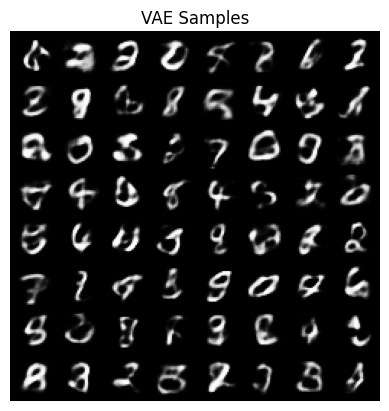

In [6]:
with torch.no_grad():

    z = torch.randn(64, 20).to(device)

    samples = vae.decode(z).view(-1, 1, 28, 28)

    grid = make_grid(samples, 8)

plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("VAE Samples")
plt.axis("off")
plt.show()


## **Part 2. DCGAN (Deep Convolutional GAN) 모델 정의 및 학습**
- Weight Initialization
  - 모델의 가중치는 평균이 0, 표준편차가 0.02인 정규분포로 초기화
  - 기존 GAN의 학습 불안정성을 줄이기 위해 DCGAN 논문에서 제안한 아이디어

- Generator (생성자)
  - Transposed Convolution: 저차원의 잠재 벡터를 고해상도 이미지로 확장
  - Batch Normalization: 각 layer의 출력을 정규화하여 학습의 안정성을 높이고 gradient vanishing 문제를 해결
  - Activation: 중간 layer에는 ReLU를 통해 빠른 학습을 진행하고, 마지막 layer에는 이미지의 픽셀 값 범위([-1, 1])를 맞추기 위해 Tanh를 사용

- Discriminator (판별자)
  - Strided Convolution: pooling 대신 stride를 사용하여 특징을 추출
  - 마지막 layer에서 sigmoid를 통해 Real/Fake 확률값 출력


참고 코드: https://github.com/Natsu6767/DCGAN-PyTorch/blob/master/dcgan.py

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)


In [8]:
# weight 초기화 함수

def weights_init(m):

    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


In [9]:
latent_size = 20

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.tconv1 = nn.ConvTranspose2d(latent_size, 256, 7, 1, 0, bias=False)
        self.bn1 = nn.BatchNorm2d(256)

        self.tconv2 = nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.tconv3 = nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(64)

        self.tconv4 = nn.ConvTranspose2d(64, 1, 3, 1, 1, bias=False)

    def forward(self, z):
        x = F.relu(self.bn1(self.tconv1(z)))   # 🤔 빈칸을 채워주세요 (Generator의 입력)
        x = F.relu(self.bn2(self.tconv2(x)))
        x = F.relu(self.bn3(self.tconv3(x)))
        x = torch.tanh(self.tconv4(x))   # 🤔 빈칸을 채워주세요 (마지막 layer 통과)
        return x


**✍️ 위에서 채운 `Generator.forward` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* Generator의 forward 코드는 무작위 잠재 벡터 z를 입력받아 저차원 벡터를 upsampling하여 28*28 크기의 신규 이미지로 합성하는 기능을 합니다. selr.tconv1(z)와 self.bn1으로 구성되어 잠재 벡터 z를 첫번째 transpose convolution layer에 전달한 후, tconv1부터 tconv3까지 거치며 이미지의 spatial크기를 단계적으로 키웁니다. 각 중간 layer마다 Batch Normalization 과 ReLU 활성화 함수를 적용하여 학습의 안정성을 높입니다.


In [10]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=4, stride=2, padding=1, bias=False)

        self.conv2 = nn.Conv2d(64, 128, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(128, 256, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(256, 1, 3, 1, 0, bias=False)

    def forward(self, x):

        x = F.leaky_relu(self.conv1(x), 0.2)
        x = F.leaky_relu(self.bn2(self.conv2(x)), 0.2)
        x = F.leaky_relu(self.bn3(self.conv3(x)), 0.2)   # 🤔 빈칸을 채워주세요 (conv3 + bn3 통과)
        x = torch.sigmoid(self.conv4(x))

        return x.view(-1, 1).squeeze(1)


**✍️ 위에서 채운 `Discriminator.forward` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* Discriminator forward 코드는 입력된 이미지가 진짜인지 가짜인지 판별하여 0부터 1사이의 확률값으로 변환하는 기능을 합니다. 입력이미지를 합성곱 레이어(conv1-conv3)에 통과시키며 채널 수를 확대하고 고차원 특징을 추출합니다. Batch Normalization을 적용하고, 기울기 소실을 방지하기 위해 LeakyReLU 활성화 함수를 사용합니다.

In [11]:
G = Generator().to(device)
D = Discriminator().to(device)

G.apply(weights_init)
D.apply(weights_init)

criterion = nn.BCELoss()

optG = optim.Adam(G.parameters(), 0.0002, betas=(0.5, 0.999))
optD = optim.Adam(D.parameters(), 0.0002, betas=(0.5, 0.999))


In [12]:
for epoch in range(epochs):

    G.train()
    D.train()

    train_lossD = 0
    train_lossG = 0

    for x, _ in train_loader:

        x = x.to(device)

        real = torch.ones(x.size(0)).to(device)
        fake = torch.zeros(x.size(0)).to(device)

        # ========== Train Discriminator ==========

        z = torch.randn(x.size(0), latent_size, 1, 1).to(device)

        fake_img = G(z)

        loss_real = criterion(D(x), real)
        loss_fake = criterion(D(fake_img.detach()), fake)

        lossD = loss_real + loss_fake

        optD.zero_grad()
        lossD.backward()
        optD.step()

        # ========== Train Generator ==========

        loss_G = criterion(D(fake_img), real)  # 🤔 빈칸을 채워주세요 (Generator는 D가 fake_img를 무엇으로 착각하길 원할까요?)

        optG.zero_grad()
        loss_G.backward()
        optG.step()

        train_lossD += lossD.item()
        train_lossG += loss_G.item()

    train_lossD /= len(train_loader)
    train_lossG /= len(train_loader)

    print(f"Epoch [{epoch+1}/{epochs}] Loss D: {train_lossD:.4f} | Loss G: {train_lossG:.4f}")


Epoch [1/15] Loss D: 0.8200 | Loss G: 1.6691
Epoch [2/15] Loss D: 0.9240 | Loss G: 1.4336
Epoch [3/15] Loss D: 0.9815 | Loss G: 1.3364
Epoch [4/15] Loss D: 1.0029 | Loss G: 1.3175
Epoch [5/15] Loss D: 0.9945 | Loss G: 1.3458
Epoch [6/15] Loss D: 0.9974 | Loss G: 1.3614
Epoch [7/15] Loss D: 0.9832 | Loss G: 1.3933
Epoch [8/15] Loss D: 0.9931 | Loss G: 1.3981
Epoch [9/15] Loss D: 0.9974 | Loss G: 1.3839
Epoch [10/15] Loss D: 0.9852 | Loss G: 1.4148
Epoch [11/15] Loss D: 0.9622 | Loss G: 1.4589
Epoch [12/15] Loss D: 0.9414 | Loss G: 1.4922
Epoch [13/15] Loss D: 0.9463 | Loss G: 1.5072
Epoch [14/15] Loss D: 0.9280 | Loss G: 1.5378
Epoch [15/15] Loss D: 0.9116 | Loss G: 1.5511


**✍️ 위에서 채운  코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* Discriminator는 진짜 이미지와 가짜 이미지를 명확히 구별하는 기능을 합니다. 이를 위해 진짜 이미지를 D에 입력한 결과가 1에 가까워지도록 loss_real 을 계산하고 가짜이미지는 0에 가까워지도록 loss_fake를 계산합니다. 두 loss를 더한 lossD로 판별자의 가중치를 업데이트합니다. Generator는 Discriminator를 속이는 최선의 가짜 이미지 생성법을 학습합니다. fake_img를 다시 D에 통과시켰을 떄 이를 1이라고 판단하도록 loss_G를 계산하여 생성자 가중치만 업데이트 합니다.

**DCGAN Sampling 시각화**

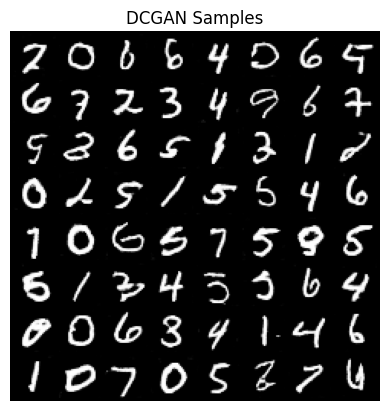

In [13]:
G.eval()

with torch.no_grad():

    z = torch.randn(64, latent_size, 1, 1).to(device)

    samples = G(z)

grid = make_grid(samples, 8, normalize=True)

plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("DCGAN Samples")
plt.axis("off")
plt.show()


## **🙋 [GAN] Question 1**
VAE와 DCGAN으로 MNIST 이미지를 생성한 결과 VAE는 흐릿한 이미지, DCGAN은 선명한 이미지가 생성된 것을 알 수 있습니다. 그 이유를 VAE와 GAN의 특징과 학습 방식을 포함하여 설명해주세요.

* VAE는 구조상 생성 결과물의 퀄리티가 떨어지고 blurry output이 나타나는 단점이 있습니다. 또, 디코더의 성능이 너무 강해 인코더 정보를 사용하지 않는 현상이 발생하거나, 사전학습되지 않은 정보 및 구도가 다른 별개 범주에 대해 단순 이미지 간 혼합 형태로 출력되는 한계가 있습니다. 반면 DCGAN은 Discriminator가 경계선 등의 이미지 정보를 세밀하게 판단하는 적대적 학습을 거칩니다. 세부특징을 학습하므로 퀄리티 높은 선명한 이미지를 생성할 수 있습니다.


## **🙋 [GAN] Question 2**
GAN 학습 과정에서 Generator와 Discriminator 중 한쪽이 너무 빨리 강해지면 어떤 문제가 발생할 수 있는지, Mode collapse 또는 Vanishing gradient 개념을 활용하여 설명해주세요.

* Discriminator 가 너무 빨리 강해지면 real 과 fake를 너무 쉽게 구분하게 됩니다. 이로 인해 Generator로 전달되는 Gradient가 사라지는 Vanishing gradient 현상이 발생하여 학습이 조기 종료됩니다. Generator가 Discriminator의 허점을 빠르게 공략할 때 Mode collapse가 발생하며 이는 생성자가 판별자를 속이는 특정 패턴으로만 생성하는 문제입니다.

## **Part 3. Diffusion Model (DDPM) 원리 구현**

- **Forward process**: 원본 이미지 $x_0$에 $t$번에 걸쳐 점진적으로 Gaussian noise를 주입하여 $x_t$를 만드는 과정. Closed-form으로 한 번에 임의의 t 시점 노이즈 이미지를 계산할 수 있음
  $$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1-\bar{\alpha}_t}\, \epsilon,\quad \epsilon \sim \mathcal{N}(0, I)$$

- **Reverse process**: 노이즈 $x_t$로부터 노이즈 $\epsilon$을 예측하는 신경망(주로 U-Net)을 학습시켜, $x_T$(순수 노이즈)부터 $x_0$까지 역으로 복원

- **손실함수의 단순화**: DDPM 논문의 핵심 기여 중 하나로, 복잡한 분포 비교 대신 신경망이 예측한 노이즈와 실제 주입된 노이즈 사이의 단순 MSE Loss만으로 학습이 가능함
  $$L_{simple} = \mathbb{E}_{t, x_0, \epsilon}\left[\, \| \epsilon - \epsilon_\theta(x_t, t) \|^2 \,\right]$$

이번 파트에서는 **forward process와 손실함수, 노이즈 예측 네트워크의 핵심 구조를 직접 코드로 구현**하며 원리를 이해합니다. 다만 DDPM은 실제로는 대규모 U-Net을 오랜 시간 학습해야 제대로 된 이미지가 나오기 때문에, 짧은 실습 환경(Colab)에서 처음부터 학습시키기엔 한계가 있습니다. 그래서 우리가 구현한 것과 동일한 원리로 학습된 **Hugging Face의 사전학습 MNIST DDPM 모델**을 불러와 실제 reverse process 결과를 확인해봅니다.


In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)


### **Noise Schedule 정의**
$\beta_t$를 선형으로 증가시키며, $\alpha_t = 1-\beta_t$, $\bar{\alpha}_t = \prod_{s=1}^{t}\alpha_s$ 를 미리 계산해둡니다.


In [15]:
T = 1000  # DDPM 논문 기준 총 diffusion step 수

beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)


def forward_diffusion(x0, t):
    """x0(원본 이미지)에 timestep t만큼의 노이즈를 주입해 x_t를 반환"""
    noise = torch.randn_like(x0)

    sqrt_ac = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    sqrt_omac = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)

    x_t = sqrt_ac * x0 + sqrt_omac * noise   # 🤔 빈칸을 채워주세요 (forward process 수식)

    return x_t, noise


**✍️ 위에서 채운 `forward_diffusion` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* forward_diffusion 함수는 DDPM의 Forward Process를 구현한 것으로, 원본 이미지 $x_0$에 임의의 타임스텝 $t$에 해당하는 가우시안 노이즈를 주입하여 노이즈가 섞인 이미지 $x_t$와 실제 주입된 노이즈 $\epsilon$을 반환하는 기능을 합니다.
 미리 계산해둔 계수 배열에서 $t$ 시점의 스케일링 값인 sqrt_alphas_cumprod[t]와 sqrt_one_minus_alphas_cumprod[t]를 추출한 뒤, 이미지 텐서 x0 (Batch, Channel, Height, Width)와 방송 연산(Broadcasting)이 가능하도록 .view(-1, 1, 1, 1)을 통해 4차원으로 형태를 맞춰 곱해줍니다.


**Forward process 시각화**: t가 커질수록 이미지가 점점 순수 노이즈에 가까워지는 것을 확인해봅시다.

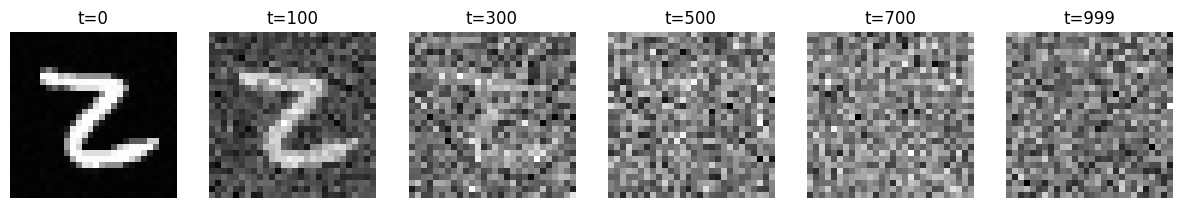

In [16]:
x0, _ = next(iter(train_loader))
x0 = x0[:1].to(device)

timesteps_to_show = [0, 100, 300, 500, 700, 999]
fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(15, 3))

for i, t_val in enumerate(timesteps_to_show):
    t = torch.tensor([t_val]).to(device)
    x_t, _ = forward_diffusion(x0, t)
    axes[i].imshow(x_t[0, 0].cpu().numpy(), cmap="gray")
    axes[i].set_title(f"t={t_val}")
    axes[i].axis("off")

plt.show()


### **U-Net 기반 노이즈 예측 네트워크**
DDPM은 노이즈가 섞인 이미지 $x_t$와 timestep $t$를 입력받아 주입된 노이즈 $\epsilon$을 예측하는 신경망을 사용합니다. 아래는 skip connection을 포함한 축소된 U-Net 구조입니다. Downsampling에서 저장해둔 feature map을 Upsampling 단계에서 다시 이어붙여(concat), 공간 정보 손실을 줄이는 것이 핵심입니다.


In [17]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return emb


class SimpleUNet(nn.Module):

    def __init__(self, time_dim=64):
        super().__init__()

        self.time_mlp = nn.Sequential(
            TimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU()
        )

        # Downsampling
        self.down1 = nn.Conv2d(1, 64, 3, padding=1)                    # 28 -> 28
        self.down2 = nn.Conv2d(64, 128, 3, stride=2, padding=1)        # 28 -> 14
        self.down3 = nn.Conv2d(128, 256, 3, stride=2, padding=1)       # 14 -> 7

        self.time_proj = nn.Linear(time_dim, 256)

        # Bottleneck
        self.bottleneck = nn.Conv2d(256, 256, 3, padding=1)            # 7 -> 7

        # Upsampling (skip connection으로 채널이 2배가 됨)
        self.up1 = nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1)   # 7 -> 14
        self.up_conv1 = nn.Conv2d(128 + 128, 128, 3, padding=1)           # skip(h2) concat

        self.up2 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)    # 14 -> 28
        self.up_conv2 = nn.Conv2d(64 + 64, 64, 3, padding=1)              # skip(h1) concat

        self.out = nn.Conv2d(64, 1, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        # Downsampling (skip connection용으로 각 단계 출력을 저장)
        h1 = F.relu(self.down1(x))      # (B, 64, 28, 28)
        h2 = F.relu(self.down2(h1))     # (B, 128, 14, 14)
        h3 = F.relu(self.down3(h2))     # (B, 256, 7, 7)

        # timestep embedding을 bottleneck 채널에 더해줌
        t_proj = self.time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)
        h3 = h3 + t_proj   # 🤔 빈칸을 채워주세요 (h3에 timestep 정보를 더해주려면?)

        h3 = F.relu(self.bottleneck(h3))

        # Upsampling + skip connection (concat)
        u1 = F.relu(self.up1(h3))                      # (B, 128, 14, 14)
        u1 = torch.cat([u1, h2], dim=1)                 # (B, 256, 14, 14)
        u1 = F.relu(self.up_conv1(u1))                  # (B, 128, 14, 14)

        u2 = F.relu(self.up2(u1))                       # (B, 64, 28, 28)
        u2 = torch.cat([u2, h1], dim=1)                  # (B, 128, 28, 28)
        u2 = F.relu(self.up_conv2(u2))                   # (B, 64, 28, 28)

        out = self.out(u2)

        return out


**✍️ 위에서 채운 `SimpleUNet.forward`의 timestep 결합 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* SimpleUNet.forward의 h3+t_proj 코드는 U-Net 모델에 현재 이미지의 노이즈 정도인 타입스텝(t) 정보를 주입하는 기능을 수행합니다. 1차원 타임스텝 $t$를 TimeEmbedding과 선형 레이어(self.time_proj)를 거쳐 256 차원 임베딩으로 변환합니다. 이후 .unsqueeze(-1).unsqueeze(-1)를 사용해 (B, 256, 1, 1) 형태의 4차원 텐서로 확장한 뒤, Downsampling의 마지막 특징 맵인 h3 (B, 256, 7, 7)에 브로드캐스팅 가산 방식으로 공간 전체 채널에 더해주는 구조로 작동합니다.

### **DDPM Loss**
예측한 노이즈와 실제 주입한 노이즈 사이의 MSE Loss입니다.


In [18]:
def ddpm_loss(model, x0):
    B = x0.size(0)

    t = torch.randint(0, T, (B,), device=device).long()

    x_t, noise = forward_diffusion(x0, t)

    predicted_noise = model(x_t, t)

    loss = F.mse_loss(predicted_noise, noise)   # 🤔 빈칸을 채워주세요 (실제 노이즈 vs 예측 노이즈)

    return loss


**✍️ 위에서 채운 `ddpm_loss` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* ddpm_loss 코드는 주입된 실제 노이즈와 모델이 예측한 노이즈간의 MSE loss를 계산하는 기능을 수행합니다. 배치별 무작위 타임스텝 $t$를 추출한 뒤, forward_diffusion으로 원본 이미지 $x_0$에 노이즈를 섞은 $x_t$와 실제 노이즈(noise)를 생성합니다.U-Net 모델이 $x_t$와 $t$를 받아 추정한 predicted_noise와 실제 주입된 noise 간의 MSE Loss를 계산하여 반환합니다.

## **🙋 [Diffusion] Question 1**
DDPM은 왜 원본 이미지 $x_0$를 직접 예측하지 않고, 이미지에 주입된 노이즈 $\epsilon$을 예측하도록 학습할까요?

* 원본 이미지 $x_0$는 구조가 복잡하고 가변적이지만, 주입된 노이즈 $\epsilon$은 평균 0과 분산 1을 갖는 정규 가우시안 분포로 목적지의 형태가 명확하고 일관되어 모델이 학습하기 훨씬 단순하고 안정적이기 때문입니다.


In [19]:
unet = SimpleUNet().to(device)

# 참고: 위에서 구현한 forward_diffusion / SimpleUNet / ddpm_loss가
# DDPM 학습의 핵심 원리 전부입니다. 다만 실제로 눈에 보이는 숫자 이미지를
# 생성할 수준까지 학습시키려면 훨씬 더 큰 모델과 긴 학습 시간이 필요합니다.
# 아래에서는 동일한 원리로 이미 충분히 학습된 사전학습 모델을 불러와
# reverse process 결과를 직접 확인해봅니다.


### **사전학습된 DDPM으로 Reverse Process 결과 확인**

Hugging Face에는 우리가 위에서 구현한 것과 동일한 원리(forward process, 노이즈 예측 U-Net, MSE loss)로 MNIST를 학습시킨 DDPM 모델이 공개되어 있습니다. `DDPMPipeline`을 불러와 실제 reverse process가 어떻게 노이즈에서 숫자 이미지를 만들어내는지 확인해봅시다.


In [20]:
!pip install -q diffusers transformers accelerate safetensors

model_index.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

FrozenDict({'num_train_timesteps': 1000, 'beta_start': 0.0001, 'beta_end': 0.02, 'beta_schedule': 'squaredcos_cap_v2', 'trained_betas': None, 'variance_type': 'fixed_small', 'clip_sample': True, 'prediction_type': 'epsilon', 'thresholding': False, 'dynamic_thresholding_ratio': 0.995, 'clip_sample_range': 1.0, 'sample_max_value': 1.0, 'timestep_spacing': 'leading', 'steps_offset': 0, 'rescale_betas_zero_snr': False, '_class_name': 'DDPMScheduler', '_diffusers_version': '0.27.2'})


  0%|          | 0/200 [00:00<?, ?it/s]

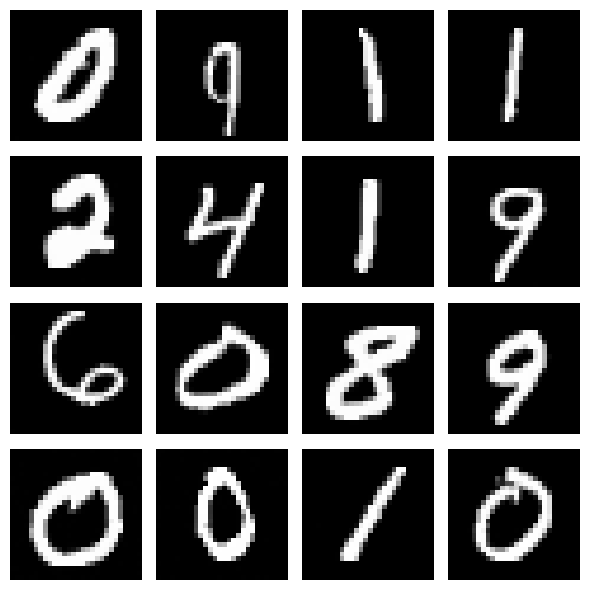

In [21]:
import torch
import matplotlib.pyplot as plt
from diffusers import DDPMPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = DDPMPipeline.from_pretrained(
    "nathanReitinger/MNIST-diffusion"
).to(device)

# Scheduler 설정 확인
print(pipe.scheduler.config)

# Reverse process
images = pipe(
    batch_size=16,
    num_inference_steps=200
).images

# 결과 확인
fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for ax, image in zip(axes.flatten(), images):
    ax.imshow(image, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

### 별도 question!
결과가 이상하게 나와서 당황하셨죠?
왜 ddpm은 앞의 vae와 gan과 다르게 일관적이지 않고 어떤건 바르게 어떤 건 완전 악필이 쓴 것처럼 나오는 걸까요?

- VAE는 평균적인 형태만 복원하려는 성질 때문에 전체적으로 뭉개지고 매끄러운 이미지 위주로 생성하며, GAN은 Mode Collapse로 인해 가장 그럴듯하고 전형적인 일부 형태 위주로 고착화되어 생성하는 경향이 있습니다. 반면 DDPM은 데이터 다양성을 그대로 보존하기 때문에 악필이나 변형된 형태까지 원본 데이터의 다양성대로 출력되기 때문입니다.

## **🙋 [Diffusion] Question 2**
VAE, GAN, Diffusion 세 모델을 **학습 안정성**, **생성 품질**, **추론(샘플링) 속도** 세 가지 관점에서 비교해주세요.

앞선 실습 사진을 보고 하는 것이 아닌 이론적으로 비교해주시면 됩니다.아무래도 실습이다보니 이 결과로 비교하는 것은 이론적으로 틀릴 수도 있어서...

- 학습 안정성 (Training Stability)

VAE: ELBO를 직접 최대화하는 명확한 목적 함수를 사용하여 매우 안정적입니다.

GAN: Generator와 Discriminator 간의 적대적 경쟁에 의존하므로 Mode Collapse나 Vanishing Gradient 같은 심각한 학습 불안정성을 겪습니다.

Diffusion: 단순화된 MSE 손실 함수($L_{\text{simple}}$)를 통해 노이즈를 예측하는 supervised regression 형태로 학습되므로, 적대적 학습 없이 매우 안정적으로 수렴합니다.


- 생성 품질 (Generation Quality & Diversity)

VAE: 데이터의 다양성은 잘 확보하지만, 확률 분포를 단순한 Gaussian/Bernoulli로 가정하고 평균적인 형태를 복원하기 때문에 결과물이 뭉개지거나 흐릿(Blurry)합니다.

GAN: 모드 붕괴로 인해 데이터 전체의 다양성을 커버하지는 못할 수 있으나, Discriminator를 직접 속이도록 고주파 세부 특징을 학습하므로 매우 선명하고 사실적인 고품질 이미지를 생성합니다.

Diffusion: 데이터 분포 전체를 넓게 커버(Mode Coverage)하는 다양성을 유지하는 동시에, 수백~수천 단계에 걸쳐 정밀하게 노이즈를 제거하므로 GAN 수준 이상의 매우 높은 품질과 사실성을 확보합니다.

- 추론/샘플링 속도 (Inference Speed)

VAE: 인코더를 통해 얻은 잠재 벡터(Latent code)를 디코더에 단 1회 통과(Single-pass)시키므로 샘플링 속도가 매우 빠릅니다.

GAN: 잠재 노이즈 벡터 $z$를 Generator에 단 1회 통과(Single-pass)시켜 바로 완성된 이미지를 얻으므로 추론 속도가 매우 빠릅니다.

Diffusion: 완전한 노이즈 $x_T$에서 출발하여 $T$번(보통 수백~수천 Step) 동안 신경망(U-Net)을 반복적으로 통과시켜 노이즈를 단계별로 제거해야 하므로 샘플링 속도가 매우 느립니다.

## **Part 4. Hugging Face `diffusers`로 사전학습 Diffusion 모델 실습**

Part 3에서 우리는 DDPM의 핵심 원리(forward process, 노이즈 예측 U-Net, MSE loss)를 직접 코드로 구현하고, MNIST 전용 사전학습 모델로 그 결과를 확인해봤습니다. 이번에는 훨씬 크고 복잡한 U-Net을 방대한 이미지-텍스트 데이터로 학습시킨 모델을 다뤄봅니다. 대표적으로 **Stable Diffusion**은 발표자료에서 다룬 것처럼 VAE + Diffusion(Latent Diffusion) + Cross-Attention 기반 Text Conditioning 구조를 가지고 있습니다.

Hugging Face의 `diffusers` 라이브러리를 사용하면 이런 사전학습 모델을 몇 줄의 코드로 불러와 사용할 수 있습니다. Colab에서는 **런타임 유형을 GPU로 설정**한 후 진행해주세요. (런타임 → 런타임 유형 변경 → T4 GPU)


In [22]:
!pip install -q diffusers transformers accelerate


### **4-1. Text-to-Image: Stable Diffusion**

프롬프트를 입력하면 그에 맞는 이미지를 생성해주는 `StableDiffusionPipeline`을 사용해봅니다. 내부적으로는 텍스트 프롬프트를 CLIP text encoder로 임베딩하고, 이를 조건으로 latent space에서 diffusion(denoising)을 수행한 뒤, VAE decoder로 pixel space 이미지를 복원합니다. (발표자료 33p의 Stable Diffusion 구조 참고)


In [23]:
import torch
from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)
pipe = pipe.to("cuda")


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

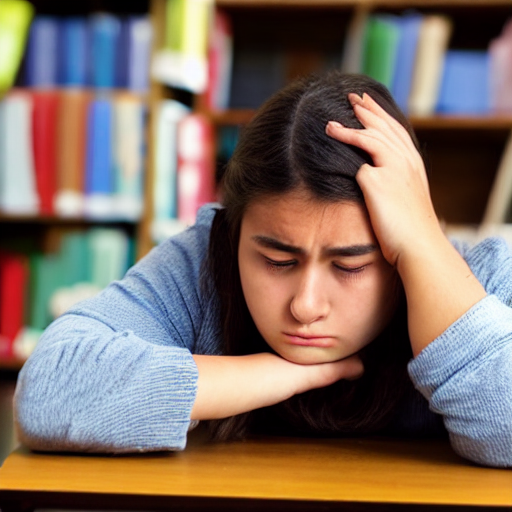

In [24]:
prompt = "A tired student who wants to go home"   # 🤔 원하는 프롬프트로 자유롭게 바꿔보세요

image = pipe(
    prompt,
    num_inference_steps=30,   # 🤔 빈칸을 채워주세요 (몇 step 만에 denoising을 마칠지, 예: 25~50)
    guidance_scale=7.5
).images[0]

image


**✍️ 위에서 채운 `num_inference_steps` 코드가 어떤 기능을 하고, 이 값이 커지거나 작아지면 결과가 어떻게 달라지는지 간단히 설명해주세요.**

* 노이즈를 제거하는 과정을 얼마나 수행할지 결정하는 파라미터입니다. 값이 작을 경우, 노이즈 제거 단계를 적게 거쳐 빠르게 이미지를 얻을 수 있지만, 노이즈가 충분히 제거되지 않아 이미지 완성도가 낮아집니다. 값이 커질 경우, 노이즈를 더 세밀하게 제거하여 고품질 이미지를 생성할 수 있습니다.

## **🙋 [Hugging Face] Question 1**
위 코드의 `guidance_scale` 파라미터는 발표자료의 **Classifier-free guidance(CFG)** 개념과 관련이 있습니다. `guidance_scale` 값을 낮추거나(예: 1.0) 높이면(예: 15.0) 생성 결과가 각각 어떻게 달라질지 예상해보고, 실제로 두 값으로 각각 이미지를 생성해 비교해주세요.

* guidance_scale을 낮췄을 땐 프롬프트 조건을 거의 무시한 채 무작위성에 의존하여 곰이 아닌 개 형태의 무채색 이미지가 생성되었습니다. 반면, 높였을 땐 학사모와 곰 형태는 반영되었으나, 가중치가 너무 높아 색상이 과도해지고 대비가 왜곡된 인공적인 이미지가 생성되었습니다.

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

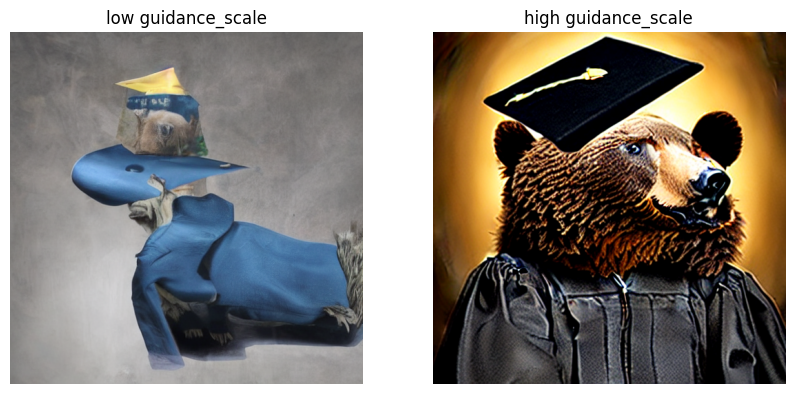

In [25]:
# 🤔 guidance_scale을 다르게 주어 두 이미지를 생성하고 비교해주세요
prompt = "a photo of a bear wearing a graduation cap, studio lighting, high quality"

image_low_cfg = pipe(prompt, num_inference_steps=30, guidance_scale=1.0).images[0]   # 🤔 빈칸을 채워주세요
image_high_cfg = pipe(prompt, num_inference_steps=30, guidance_scale=15.0).images[0]  # 🤔 빈칸을 채워주세요

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image_low_cfg)
axes[0].set_title("low guidance_scale")
axes[0].axis("off")
axes[1].imshow(image_high_cfg)
axes[1].set_title("high guidance_scale")
axes[1].axis("off")
plt.show()


**✍️ 위에서 채운 `guidance_scale` 비교 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* guidance_scale 비교 코드는 Classifier-Free Guidance(CFG) 값에 따른 이미지 생성 변화를 확인하는 기능을 합니다. 동일한 프롬프트와 타임스텝 수(num_inference_steps=30)를 유지한 채, guidance_scale 매개변수만 낮게(1.0)와 높게(15.0) 다르게 부여하여 두 개의 이미지를 각각 생성합니다. 이후 matplotlib.subplots를 활용해 두 결과를 1행 2열의 격자로 시각적으로 비교 배치하도록 구성되어 있습니다

### **4-2. Sampler(Scheduler) 교체해보기**

발표자료 33p에서 언급했듯 Stable Diffusion은 하나로 고정된 모델이 아니라, denoising에 사용하는 sampler(scheduler)를 자유롭게 교체할 수 있는 구조입니다. 기본 스케줄러 대신 DDIM 스케줄러로 교체하여 더 적은 step으로도 이미지를 생성해봅니다.


  0%|          | 0/20 [00:00<?, ?it/s]

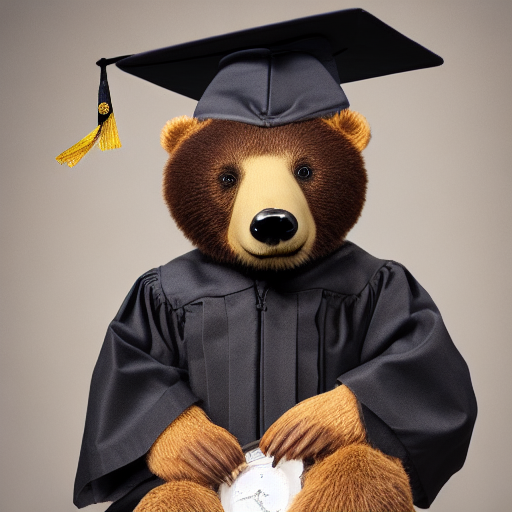

In [26]:
from diffusers import DDIMScheduler

pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

image_ddim = pipe(
    prompt,
    num_inference_steps=20,  # DDPM보다 훨씬 적은 step
    guidance_scale=7.5
).images[0]

image_ddim


## **🙋 [Hugging Face] Question 2**
DDIM 스케줄러가 기본 스케줄러보다 적은 step으로도 그럴듯한 이미지를 생성할 수 있는 이유를 Part 3에서 다룬 DDPM의 reverse process와 비교하여 설명해주세요.

* DDIM은 DDPM과 달리 비마르코프적(non-Markovian) reverse process를 사용할 수 있고, deterministic sampling(η=0)을 통해 중간 timestep을 건너뛰면서도 이미지의 구조를 유지할 수 있어 적은 step으로 샘플링할 수 있습니다.

## **🙋 [Hugging Face] Question 3**
직접 해보기 + 허깅 페이스와 인사하기

허깅페이스의 모델 api 활용하기/space에서 모델 3개 이상 활용해보기
둘 중 하나를 택해서 실행하고 간단하게 써본 경험을 공유해주세요!

[예시 노션 링크](https://app.notion.com/p/Hugging-face-3a059e60d52d80f49489f7a3c3ef6648?source=copy_link)

Hugging Face Space 모델 활용 보고서
1. 실습 개요

사용 모델: Stable Diffusion 3.5 Large (stabilityai/stable-diffusion-3.5-large)

목적: 동일한 주제('집에 가고 싶어 하는 학생')에 대해 화풍과 표현 방식을 다르게 설정한 3가지 프롬프트를 입력하고, 생성된 이미지의 표현 능력 및 프롬프트 반영도를 비교 평가함.

2. 이미지 생성 결과 및 분석

결과 1. 감성적인 애니메이션 일러스트 스타일

프롬프트: A anime-style illustration of a tired student staring out the classroom window during a sunset lecture, dreaming of home, warm cozy evening sunlight, soft shadows, highly detailed

분석: 노을빛이 비치는 교실 창가에 엎드린 학생의 모습을 완벽하게 구현함. 빛의 굴절, 창밖 풍경의 따뜻한 색감, 아련한 감정선 표현이 매우 정교함.

결과 2. 카툰/디지털 아트 스타일

프롬프트: A humorous cartoon-style digital art of a student sitting at a desk with a huge thought bubble above their head showing a warm cozy bed, looking exhausted, dynamic expression, vibrant colors

분석: 학생의 머리 위에 침대를 상상하는 말풍선(thought bubble)을 명확하게 표현함. 직관적인 귀여운 화풍으로 '집에 가고 싶다'는 유쾌한 의도를 가장 충실히 반영함.

결과 3. 시네마틱 실사 사진 스타일

프롬프트:A cinematic photo of a lonely student in a crowded lecture hall, sitting near the window and packing their backpack early, dramatic lighting, depth of field, photorealistic, 8k resolution

분석: 대형 강의실 안에서 가방을 메고 있는 학생의 피사계 깊이(Depth of Field) 및 조명을 실사 영화처럼 사실감 있게 구현함. 인물의 복잡한 구도와 심리적 아련함을 정밀하게 표현함.

3. 종합 후기

장점: 프롬프트에서 지정한 '화풍(Anime, Cartoon, Cinematic)'과 '상황(노을, 말풍선, 대형 강의실)'을 정확히 구분하여 스타일 변환 능력이 뛰어남.

아쉬운 점: 텍스트 길이가 길어지거나 복잡한 심리 묘사가 포함될 때 세부 오브젝트의 형태가 약간 단순화되는 경향이 있음.

결론: 별도의 GPU 코딩 환경 구축 없이도 Hugging Face Space를 통해 SOTA Text-to-Image 모델의 표현력과 프롬프트 추론 능력을 손쉽게 검증할 수 있었음.

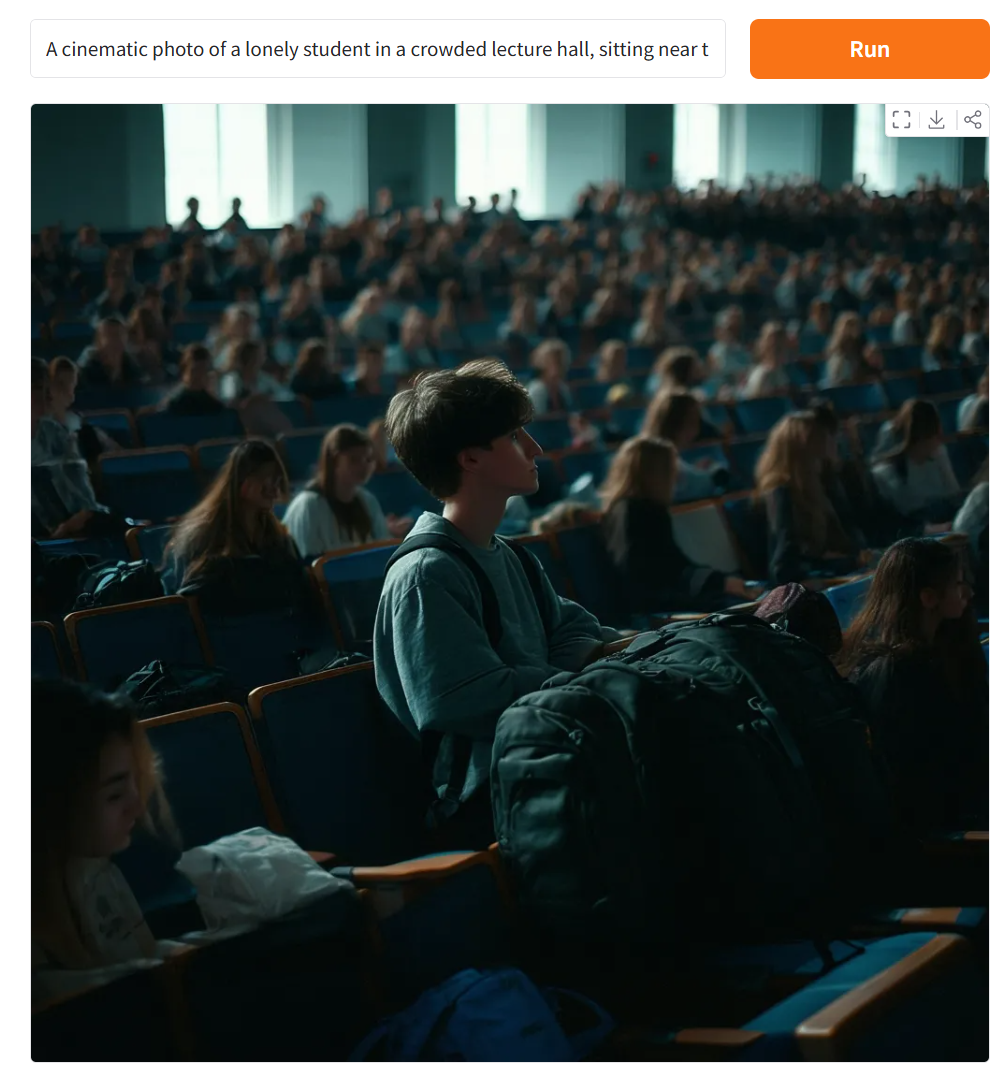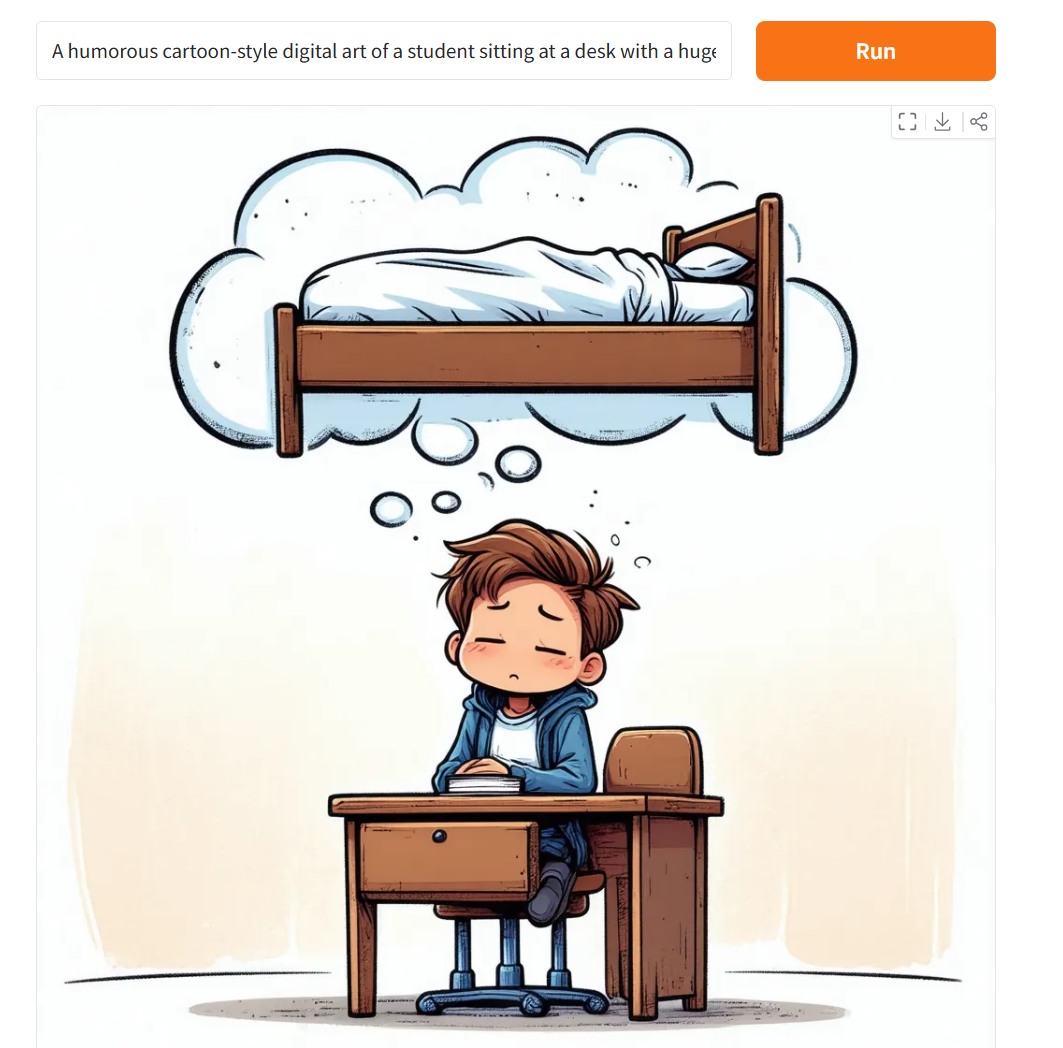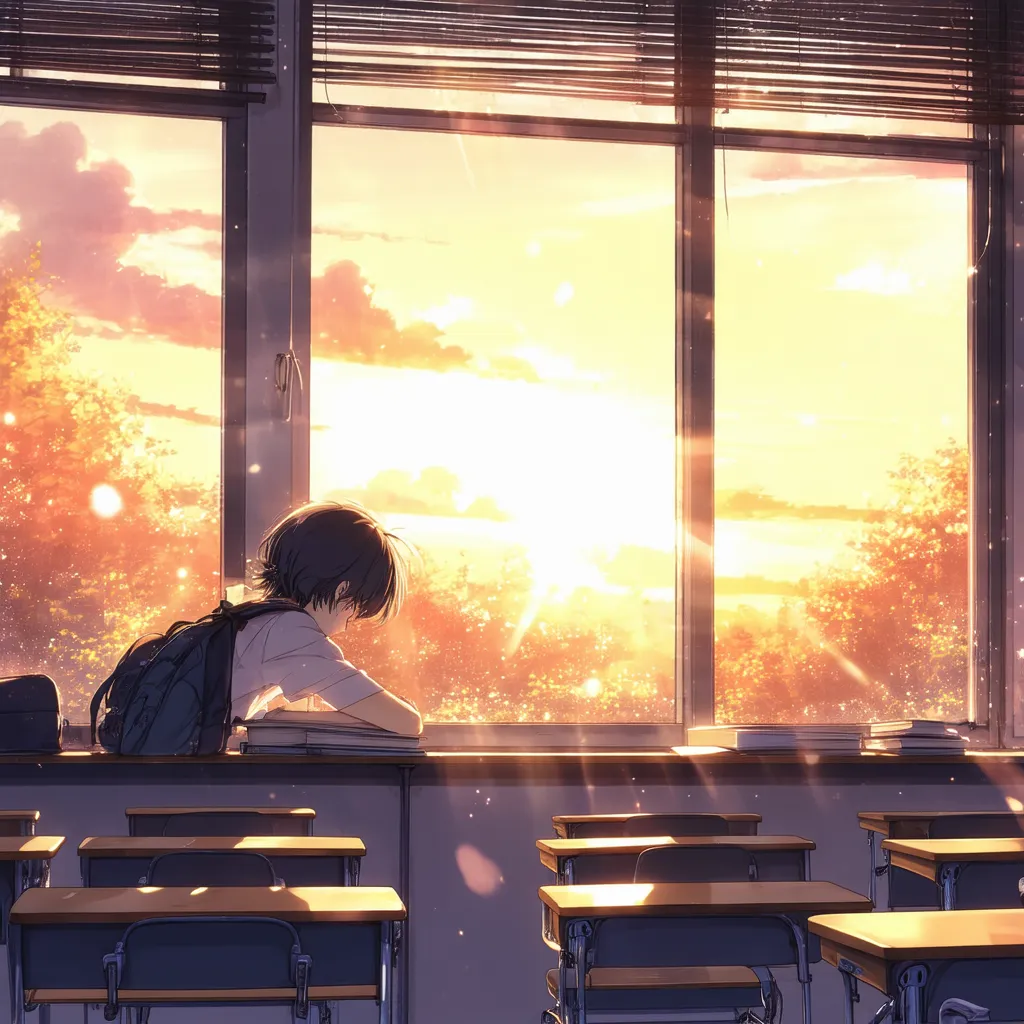


## 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): 개념이해 및 문법 설명

- **AI가 이 실험에는 틀린 답을 준 사례** —
  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: 본인 출력값과 대조, ppt 자료 확인

- **실제 대화 내역** 붙여넣기:

```
https://chatgpt.com/c/6a9e4931-1910-83ee-b99b-e43b43baf149
reparameterize 가 무슨 의미인지 이 이미지를 바탕으로 자세하게 설명해줘

VAE에서 ELBO loss의 핵심은 딱 2가지입니다.

$$ \boxed{ \mathcal L_{\text{ELBO}} = \underbrace{\mathbb E_{q_\phi(z|x)}[\log p_\theta(x|z)]}_{\text{Reconstruction}} - \underbrace{D_{KL}(q_\phi(z|x)\|p(z))}_{\text{Regularization}} } $$
1. Reconstruction Loss

latent \(z\)로 원래 입력 \(x\)를 얼마나 잘 복원하느냐

$$ \mathbb E[\log p(x|z)] $$
Encoder: \(x\rightarrow z\)
Decoder: \(z\rightarrow \hat{x}\)
원본 \(x\)와 복원된 \(\hat{x}\)가 비슷하도록 학습

👉 "복원을 잘해라"

2. KL Divergence

Encoder가 만든 latent 분포 \(q(z|x)\)가 우리가 원하는 prior \(p(z)\)와 비슷하도록

보통

$$ p(z)=N(0,I) $$

를 사용합니다.

$$ D_{KL}(q(z|x)\|p(z)) $$

가 작아지도록 합니다.

👉 "latent space를 너무 제멋대로 만들지 마라"

그래서 VAE의 핵심 trade-off
$$ \boxed{ \text{좋은 복원} \quad+\quad \text{규칙적인 latent space} } $$

입니다.

조금 더 직관적으로 말하면:

Reconstruction은 "이미지를 잘 기억해라"이고, KL은 "latent 공간을 예쁘고 연속적으로 정리해라"입니다.

그래서 둘 사이에 trade-off가 생깁니다.

KL을 너무 약하게 → 복원은 잘하지만 latent space가 엉망
KL을 너무 강하게 → latent space는 깔끔하지만 복원이 흐릿해질 수 있음

그리고 실제 구현에서는 ELBO를 최대화하는 대신 보통 ELBO의 음수인 loss를 최소화합니다:

$$ \boxed{ \text{VAE Loss} = \text{Reconstruction Loss} + D_{KL}(q(z|x)\|p(z)) } $$

한 줄 암기:

VAE = "잘 복원하되, latent distribution은 \(N(0,I)\)에 가깝게 만들어라."

class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=4, stride=2, padding=1, bias=False)

        self.conv2 = nn.Conv2d(64, 128, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(128, 256, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(256, 1, 3, 1, 0, bias=False)

    def forward(self, x):

        x = F.leaky_relu(self.conv1(x), 0.2)
        x = F.leaky_relu(self.bn2(self.conv2(x)), 0.2)
        x = F.leaky_relu(self.bn3(self.conv4(x)), 0.2)   # 🤔 빈칸을 채워주세요 (conv3 + bn3 통과)
        x = torch.sigmoid(self.conv4(x))

        return x.view(-1, 1).squeeze(1) 여기서 stride =2 의미가 뭐야

여기서 stride=2는 Conv2d의 필터(kernel)가 이미지를 움직일 때 한 번에 2칸씩 이동한다는 의미입니다.

1. stride=1이면

예를 들어 이미지가 이렇게 있다고 해봅시다.

1 2 3 4 5
6 7 8 9 10
...

kernel_size=3, stride=1이면 필터가

[■■■]
[■■■]  → 한 칸 이동
[■■■]

처럼 1칸씩 이동합니다.

2. stride=2이면
[■■■]
[■■■]  → 두 칸 이동
[■■■]

즉,

stride=1 :  → → → →
stride=2 :  →   →   →

처럼 2픽셀씩 건너뛰면서 convolution합니다.

따라서 계산 결과인 feature map의 크기가 작아집니다.

3. 지금 코드에서는 왜 stride=2를 쓰나?

첫 번째 convolution을 보면:

self.conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=64,
    kernel_size=4,
    stride=2,
    padding=1
)

MNIST처럼 입력이 28 × 28이라고 하면,

$$ 28\times28 $$

크기의 이미지를 convolution한 후 대략

$$ 14\times14 $$

로 줄입니다.

즉,

28 × 28
   ↓ Conv (stride=2)
14 × 14
   ↓ Conv (stride=2)
 7 × 7

처럼 이미지의 공간 크기를 줄이는 역할을 합니다.

4. 이 코드에서는 계속 절반으로 줄어든다

대략적으로 보면:

입력
1 × 28 × 28

      ↓ conv1 (stride=2)

64 × 14 × 14

      ↓ conv2 (stride=2)

128 × 7 × 7

      ↓ conv3 (stride=2)

256 × 4 × 4

      ↓ conv4

1 × 1 × 1

여기서 64, 128, 256은 채널 수이고,

28 → 14 → 7 → 4 → 1은 이미지의 가로/세로 크기입니다.

🔑 한 줄로 기억하면

stride=2 = convolution 필터가 2픽셀 간격으로 이동 → feature map의 공간 크기를 줄인다.

그래서 GAN의 Discriminator에서는 stride=2를 이용해 이미지 크기를 점점 줄이면서 중요한 특징을 추출하는 경우가 많습니다.

참고로 올려주신 코드에는 한 가지 오타도 있습니다. 주석의 conv3 + bn3 부분은 현재 conv4를 사용하고 있어서, 의도대로라면 self.conv3(x)가 들어가야 합니다.

reakyrelu 활성화 함수가 뭔지 간단하고 핵심만 요약해서 설명해주

아마 Leaky ReLU를 말하는 것 같아요. 핵심만 보면:

$$ \boxed{f(x)=\max(\alpha x,x)} $$

즉,

\(x>0\) → 그대로 \(x\)
\(x<0\) → 완전히 0으로 만들지 않고 **작은 값 \(\alpha x\)**로 통과

예를 들어 \(\alpha=0.2\)라면:

$$ x=-5 \rightarrow -1 $$
ReLU와 비교
	양수	음수
ReLU	\(x\)	0
Leaky ReLU	\(x\)	\(0.2x\)
왜 쓰나?

일반 ReLU는 음수 영역에서 gradient가 0이 되어 뉴런이 학습을 못 하는 Dying ReLU 문제가 생길 수 있습니다.

Leaky ReLU는 음수에서도 작은 gradient를 남겨서:

$$ \boxed{\text{음수에서도 gradient가 흐르게 한다}} $$

는 것이 핵심입니다.

아까 코드의

F.leaky_relu(x, 0.2)

에서 0.2가 바로 \(\alpha\), 즉 음수 영역의 기울기입니다.

```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은? CFG scale과 inference step 수치 변화에 따른 이미지 붕괴 현상과 과유불급의 한계를 직접 관찰하고, 텍스트 반영도와 이미지 품질 사이의 최적의 균형점을 직접 평가하여 선정한 것

수고하셨습니다 ☺️